### Import LIbraries

In [1]:
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot
from matplotlib.ticker import FormatStrFormatter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras import backend as K

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.preprocessing import StandardScaler
from datetime import datetime
import sys

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

USE_CUDA = False
EPOCHS = 20
comms_round = 20

2024-05-26 22:59:46.012021: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-26 22:59:46.012120: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-26 22:59:46.012713: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-05-26 22:59:46.077176: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-26 22:59:47.063491: W tensorflow/compiler/

### Dataset

In [2]:
%store -r FD1_X_Train
%store -r FD1_X_Test

%store -r FD1_X_Train_st
%store -r FD1_X_Test_st

%store -r FD1_y_Train
%store -r FD1_y_Test

merged_dataset = pd.concat([FD1_X_Train_st, FD1_y_Train], axis=1)

In [3]:
feature_columns = ['time_cycles', 'LPC_Outlet_Temperature', 'HPC_Outlet_Temperature', 'LPT Outlet Temperature', 'Bypass-Duct Pressure', 
                'HPC Outlet Pressure', 'Physical Fan Speed', 'Physical Core Speed', 'HPC Outlet Static Pressure',
                'Ratio of Fuel Flow to Ps30', 'Corrected Fan Speed', 'Bypass Ratio', 'Bleed Enthalpy',
                'High-Pressure Turbines Cool Air Flow', 'Low-Pressure Turbines Cool Air Flow']

features = merged_dataset[feature_columns]

labels = merged_dataset['RUL']

# Split the data into training and testing sets
train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.3, random_state=0)

### Data Partition

In [4]:
num_edge_devices = 10  

samples_per_device = len(merged_dataset) // num_edge_devices

edge_data_partition_1 = merged_dataset.iloc[0:samples_per_device]
edge_data_partition_2 = merged_dataset.iloc[samples_per_device:2*samples_per_device]
edge_data_partition_3 = merged_dataset.iloc[2*samples_per_device:3*samples_per_device]
edge_data_partition_4 = merged_dataset.iloc[3*samples_per_device:4*samples_per_device]
edge_data_partition_5 = merged_dataset.iloc[4*samples_per_device:5*samples_per_device]
edge_data_partition_6 = merged_dataset.iloc[5*samples_per_device:6*samples_per_device]
edge_data_partition_7 = merged_dataset.iloc[6*samples_per_device:7*samples_per_device]
edge_data_partition_8 = merged_dataset.iloc[7*samples_per_device:8*samples_per_device]
edge_data_partition_9 = merged_dataset.iloc[8*samples_per_device:9*samples_per_device]
edge_data_partition_10 = merged_dataset.iloc[9*samples_per_device:]

#### Train, Test split for each one of the 10 datasets

In [5]:
datasets = []

for i, df in enumerate([edge_data_partition_1, edge_data_partition_2, edge_data_partition_3, edge_data_partition_4, edge_data_partition_5, edge_data_partition_6, edge_data_partition_7, edge_data_partition_8, edge_data_partition_9, edge_data_partition_10]):  
    
    features = df[feature_columns]
    labels = df['RUL']
    
    # Split data into training and testing sets
    train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.3, random_state=0)
    
    # Append dataset dictionary to the list
    datasets.append({
        'name': f'dataset_{i+1}',
        'train_features': train_features,
        'test_features': test_features,
        'train_labels': train_labels,
        'test_labels': test_labels
    })

#### FedProx Aggrgation Function

In [6]:
def fedprox_update(global_weights, client_weights, mu):
    updated_weights = []
    for g_w, c_w in zip(global_weights, client_weights):
        updated_w = c_w - mu * (c_w - g_w)
        updated_weights.append(updated_w)
    return updated_weights

In [9]:
def sum_scaled_weights(scaled_weight_list):
    '''Return the sum of the listed scaled weights. The is equivalent to scaled avg of the weights'''
    avg_grad = list()
    #get the average grad accross all client gradients
    for grad_list_tuple in zip(*scaled_weight_list):
        layer_mean = tf.math.reduce_mean(grad_list_tuple, axis=0)
        avg_grad.append(layer_mean)

    return avg_grad

#### LSTM Model

In [7]:
def create_lstm_model(input_shape):
    model = Sequential([
        layers.Reshape((input_shape, 1), input_shape=(input_shape,)),
        layers.LSTM(128, activation="relu", return_sequences=True),
        layers.LSTM(64, activation="relu", return_sequences=True),
        layers.LSTM(32, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
    return model


input_shape = len(train_features.columns)
lstm_model = create_lstm_model(input_shape)

2024-05-26 23:00:08.380850: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-05-26 23:00:08.537783: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-05-26 23:00:08.541167: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

#### Evaluation Function

In [8]:
def evaluate_model(model, test_features, test_labels):
    predictions = model.predict(test_features)
    mae = mean_absolute_error(test_labels, predictions)
    mape = mean_absolute_percentage_error(test_labels, predictions)
    rmse = mean_squared_error(test_labels, predictions, squared=False)
    return mae, mape, rmse

### Federated Learning System with FedProx AGGREGATION

In [10]:
global_model = create_lstm_model(input_shape)
mu=0.01

global_stats_mae = pd.DataFrame(columns=['Round', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])
global_stats_mape = pd.DataFrame(columns=['Round', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])
global_stats_rmse = pd.DataFrame(columns=['Round', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])

for comm_round in range(comms_round):
    print('Round', comm_round)
    global_weights = global_model.get_weights()

    for dataset in datasets:
        local_model = create_lstm_model(input_shape)
        local_model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(), metrics='MAE')

        def scheduler(epoch):
            if epoch < 5:
                return 0.001
            else:
                return 0.0001

        callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=0)

        local_model.set_weights(global_weights)

        history = local_model.fit(dataset['train_features'], dataset['train_labels'], epochs=EPOCHS, callbacks=[callback])

        for dataset_1 in datasets:
            mae, mape, rmse = evaluate_model(local_model, dataset_1['test_features'], dataset_1['test_labels'])
            print(f'Evaluation results for {dataset["name"]} on {dataset_1["name"]} in round {comm_round}: MAE={mae}, MAPE={mape}, RMSE={rmse}')            

        mae, mape, rmse = evaluate_model(local_model, dataset['test_features'], dataset['test_labels'])
        print(f'Evaluation results for {dataset["name"]} on itself in round {comm_round}: MAE={mae}, MAPE={mape}, RMSE={rmse}')
        if mae is not None:
            dataset['weights'] = local_model.get_weights()
        else:
            dataset['weights'] = global_weights

        K.clear_session()

    average_weights = sum_scaled_weights([x['weights'] for x in datasets])

    updated_weights = fedprox_update(global_weights, average_weights, mu)

    global_model.set_weights(updated_weights)

    global_row_mae = [comm_round]
    global_row_mape = [comm_round]
    global_row_rmse = [comm_round]

    for dataset in datasets:
        mae, mape, rmse = evaluate_model(global_model, dataset['test_features'], dataset['test_labels'])
        global_row_mae.append(mae)
        global_row_mape.append(mape)
        global_row_rmse.append(rmse)
        print(f'Global evaluation results for {dataset["name"]} in round {comm_round}: MAE={mae}, MAPE={mape}, RMSE={rmse}')

    global_stats_mae.loc[len(global_stats_mae)] = global_row_mae
    global_stats_mape.loc[len(global_stats_mape)] = global_row_mape
    global_stats_rmse.loc[len(global_stats_rmse)] = global_row_rmse

print("Training completed.")

Round 0
Epoch 1/20


2024-05-26 23:01:10.461700: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x733cd8023270 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-05-26 23:01:10.461731: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2024-05-26 23:01:10.468868: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-05-26 23:01:10.523337: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8902
2024-05-26 23:01:10.579601: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


46/46 [==============================] - 6s 33ms/step - loss: 6258.9277 - MAE: 66.0385 - lr: 0.0010
Epoch 2/20
46/46 [==============================] - 2s 33ms/step - loss: 628.7169 - MAE: 20.3454 - lr: 0.0010
Epoch 3/20
46/46 [==============================] - 2s 34ms/step - loss: 309.2600 - MAE: 13.4075 - lr: 0.0010
Epoch 4/20
46/46 [==============================] - 2s 33ms/step - loss: 333.3244 - MAE: 13.9960 - lr: 0.0010
Epoch 5/20
46/46 [==============================] - 2s 33ms/step - loss: 292.0197 - MAE: 12.9614 - lr: 0.0010
Epoch 6/20
46/46 [==============================] - 2s 33ms/step - loss: 269.9409 - MAE: 12.0070 - lr: 1.0000e-04
Epoch 7/20
46/46 [==============================] - 2s 33ms/step - loss: 265.6964 - MAE: 11.8626 - lr: 1.0000e-04
Epoch 8/20
46/46 [==============================] - 2s 33ms/step - loss: 262.5219 - MAE: 11.7001 - lr: 1.0000e-04
Epoch 9/20
46/46 [==============================] - 2s 33ms/step - loss: 263.7330 - MAE: 11.7821 - lr: 1.0000e-04
Epoc

In [11]:
# save model to storage
global_model.save(f'federated/model_FedProx_{EPOCHS}_{comms_round}_{int(datetime.now().timestamp())}')

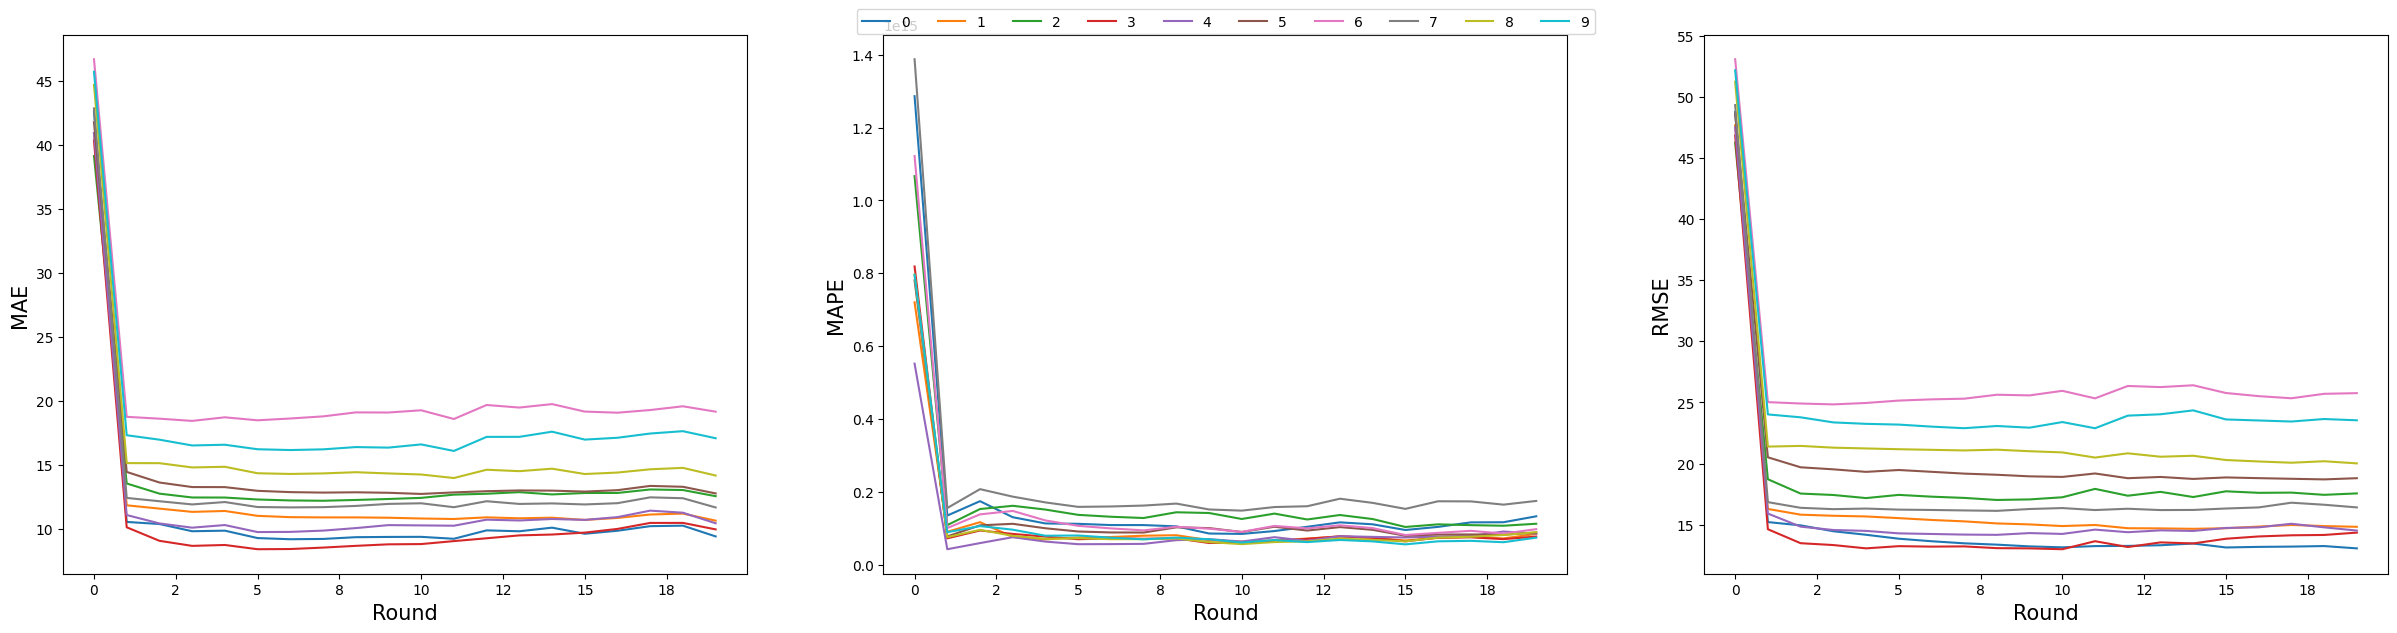

In [12]:
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(30, 7))
ax1.plot(global_stats_mae[global_stats_mae.columns[1:11]], label='train')
# ax1.legend(global_stats_mae.columns[1:], bbox_to_anchor=(0.853, 1.16), ncol=10)
ax1.set_ylabel('MAE', fontsize=15)
ax1.set_xlabel('Round', fontsize=15)
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

ax2.plot(global_stats_mape[global_stats_mape.columns[1:11]], label='train')
ax2.legend(global_stats_mape.columns[1:11], bbox_to_anchor=(1.05, 1.06), ncol=10)
ax2.set_ylabel('MAPE', fontsize=15)
ax2.set_xlabel('Round', fontsize=15)
ax2.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

ax3.plot(global_stats_rmse[global_stats_rmse.columns[1:11]], label='train')
# ax3.legend(global_stats_rmse.columns[1:], bbox_to_anchor=(0.853, 1.16), ncol=10)
ax3.set_ylabel('RMSE', fontsize=15)
ax3.set_xlabel('Round', fontsize=15)
ax3.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
pyplot.savefig(f'federated-metrics-datasets_FedProx_{EPOCHS}_{comms_round}.png', bbox_inches='tight', dpi=400)

In [13]:
global_stats_mae['A'] = (global_stats_mae['0'] + global_stats_mae['1'] + global_stats_mae['2'] + global_stats_mae['3'] +
                         global_stats_mae['4'] + global_stats_mae['5'] + global_stats_mae['6'] + global_stats_mae['7'] +
                         global_stats_mae['8'] + global_stats_mae['9']) / 10
global_stats_mape['A'] = (global_stats_mape['0'] + global_stats_mape['1'] + global_stats_mape['2'] + global_stats_mape[
    '3'] + global_stats_mape['4'] + global_stats_mape['5'] + global_stats_mape['6'] + global_stats_mape['7'] +
                          global_stats_mape['8'] + global_stats_mape['9']) / 10
global_stats_rmse['A'] = (global_stats_rmse['0'] + global_stats_rmse['1'] + global_stats_rmse['2'] + global_stats_rmse[
    '3'] + global_stats_rmse['4'] + global_stats_rmse['5'] + global_stats_rmse['6'] + global_stats_rmse['7'] +
                          global_stats_rmse['8'] + global_stats_rmse['9']) / 10

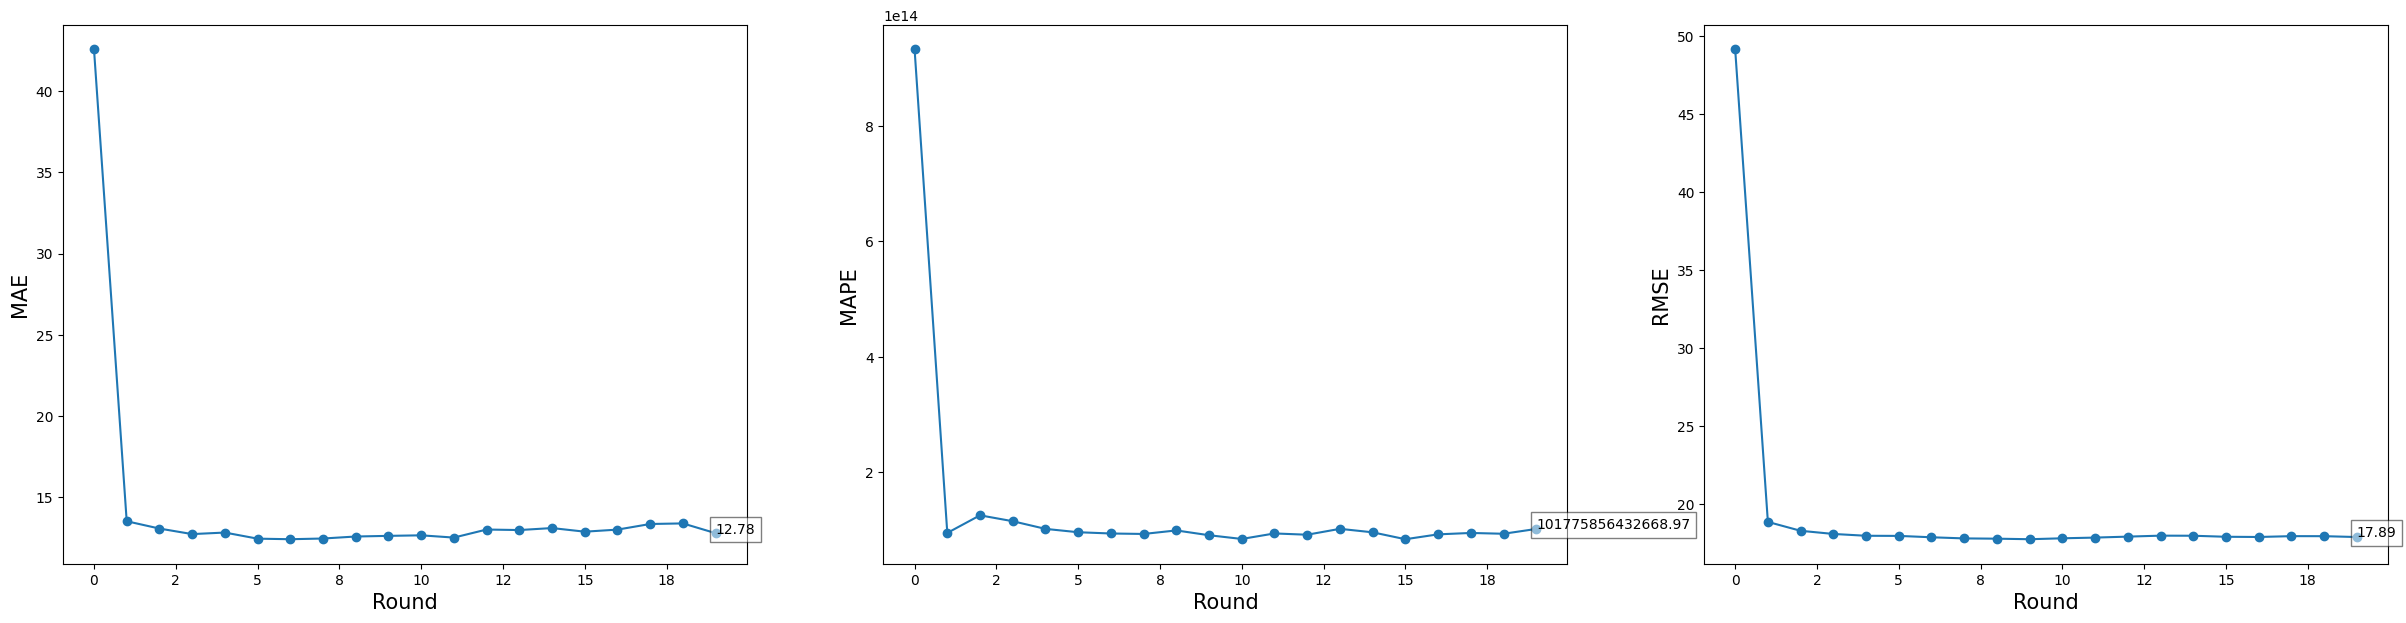

In [14]:
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(30, 7))

# Plot MAE
ax1.plot(global_stats_mae['A'], label='train', marker='o')
ax1.set_ylabel('MAE', fontsize=15)
ax1.set_xlabel('Round', fontsize=15)
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# Plot MAPE
ax2.plot(global_stats_mape['A'], label='train', marker='o')
ax2.set_ylabel('MAPE', fontsize=15)
ax2.set_xlabel('Round', fontsize=15)
ax2.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# Plot RMSE
ax3.plot(global_stats_rmse['A'], label='train', marker='o')
ax3.set_ylabel('RMSE', fontsize=15)
ax3.set_xlabel('Round', fontsize=15)
ax3.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))


ax1.text(19, global_stats_mae['A'][19], f'{global_stats_mae["A"][19]:.2f}', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
ax2.text(19, global_stats_mape['A'][19], f'{global_stats_mape["A"][19]:.2f}', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
ax3.text(19, global_stats_rmse['A'][19], f'{global_stats_rmse["A"][19]:.2f}', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))

pyplot.savefig(f'federated-metrics_FedProx_{EPOCHS}_{comms_round}.png', bbox_inches='tight', dpi=400)